# NB09: 5가지 제약 레이어 점수화 — Constraint Layers (Step 2)

**목적**: H3 그리드 셀마다 5가지 독립적 제약 점수를 계산. Tableau에서 사용자가 On/Off 토글 시 실시간 필터링.

| Layer | Type | Score Logic |
|-------|------|-------------|
| 1. 공역 (Airspace) | Hard Filter | 0 = 비행금지, 1 = 가능 |
| 2. 장애물 (Obstacle) | Soft Filter | 반경 200m 내 >15층 건물 수에 반비례 |
| 3. 소음 (Noise) | Weight Filter | 저층 주거 밀집 → 낮은 점수 |
| 4. 지형 (Terrain) | Zone Filter | 경사도<5° → 1.0, 5~15° → 0.5, >15° → 0.0 |
| 5. 기상 (Weather) | Weight Filter | 평균 풍속에 반비례 |

**종합 점수**: `composite = ∏(active layers)` (곱셈식 → 하나라도 0이면 탈락)

**입력**: `processed/delivery_urgency_grid.gpkg`, 건물/경사도/공역/기상 데이터  
**출력**: `processed/constraint_layers.gpkg` (H3 grid + 5개 점수 컬럼)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
OUT = BASE / "processed"

# H3 그리드 (NB08 출력)
gdf = gpd.read_file(OUT / "delivery_urgency_grid.gpkg")
print(f"H3 그리드: {len(gdf)} 셀")

H3 그리드: 1947 셀


## Layer 1: 공역 제약 (Airspace) — Hard Filter

서울공항(성남 비행장) 관제권 P-73/R-75 기반.  
> 데이터 미확보 시 관제권 중심 좌표 + 반경으로 근사 생성

In [2]:
from shapely.geometry import Point

airspace_path = OUT / "airspace_constraint.gpkg"

if airspace_path.exists():
    # NB07에서 생성된 공역 데이터 사용
    airspace = gpd.read_file(airspace_path)
    print(f"공역 제약 데이터 로드: {len(airspace)} zones")
else:
    # 근사값: 서울공항 관제권 (P-73 중심: 37.4449, 127.1141, 반경 ~9.3km)
    # 실제 P-73은 복잡한 다각형이지만, 원형으로 근사
    print("⚠ 공역 데이터 미확보 — 서울공항 P-73 관제권을 원형으로 근사")
    seoul_airbase = Point(127.1141, 37.4449)
    # EPSG:5179로 변환 후 버퍼 적용 (미터 단위)
    airbase_5179 = gpd.GeoDataFrame(
        {"name": ["P-73 서울공항 관제권"]},
        geometry=[seoul_airbase], crs="EPSG:4326"
    ).to_crs(epsg=5179)
    airbase_5179["geometry"] = airbase_5179.buffer(9300)  # 반경 9.3km
    airspace = airbase_5179.to_crs(epsg=4326)
    print(f"  관제권 근사 원: 중심 (37.4449, 127.1141), 반경 9.3km")

# 각 H3 셀이 관제권 내부에 있는지 체크
hex_centers = gpd.GeoDataFrame(
    gdf[["h3_index"]],
    geometry=gpd.points_from_xy(gdf["lon"], gdf["lat"]),
    crs="EPSG:4326",
)

in_airspace = gpd.sjoin(hex_centers, airspace[["geometry"]], predicate="within", how="left")
gdf["score_airspace"] = np.where(in_airspace["index_right"].notna(), 0.0, 1.0)

n_restricted = (gdf["score_airspace"] == 0).sum()
print(f"\n공역 제한 셀: {n_restricted}/{len(gdf)} ({n_restricted/len(gdf)*100:.1f}%)")

⚠ 공역 데이터 미확보 — 서울공항 P-73 관제권을 원형으로 근사
  관제권 근사 원: 중심 (37.4449, 127.1141), 반경 9.3km

공역 제한 셀: 1683/1947 (86.4%)


## Layer 2: 장애물 (Obstacle) — Soft Filter

반경 200m 내 고층 건물(>15층) 밀집도. 건물 층수 데이터가 없으면 대형 건물 면적(>1000m²)으로 대체.

In [3]:
bldg_path = OUT / "seongnam_buildings.gpkg"

if bldg_path.exists():
    bldg = gpd.read_file(bldg_path, layer="buildings_5179")
    
    # 층수 데이터 있으면 >15층, 없으면 대형 건물(>1000m²)로 대체
    if "est_floors" in bldg.columns and bldg["est_floors"].notna().any():
        tall_bldg = bldg[bldg["est_floors"] > 15].copy()
        print(f"고층 건물 (>15층): {len(tall_bldg)}동")
    else:
        bldg["area_m2"] = bldg.geometry.area
        tall_bldg = bldg[bldg["area_m2"] > 1000].copy()
        print(f"대형 건물 (>1000m², 고층 대용): {len(tall_bldg)}동")
    
    # H3 셀 중심을 EPSG:5179로 변환 후 200m 버퍼 내 고층 건물 수 카운트
    hex_5179 = gpd.GeoDataFrame(
        gdf[["h3_index"]],
        geometry=gpd.points_from_xy(gdf["lon"], gdf["lat"]),
        crs="EPSG:4326",
    ).to_crs(epsg=5179)
    hex_5179["geometry"] = hex_5179.buffer(200)
    
    joined = gpd.sjoin(hex_5179, tall_bldg[["geometry"]], predicate="intersects", how="left")
    obstacle_count = joined.groupby("h3_index")["index_right"].count().reset_index()
    obstacle_count.columns = ["h3_index", "tall_bldg_count"]
    
    gdf = gdf.merge(obstacle_count, on="h3_index", how="left")
    gdf["tall_bldg_count"] = gdf["tall_bldg_count"].fillna(0)
    
    # 점수화: 0~max → 1.0~0.3 (완전 차단은 안 함, soft filter)
    max_count = gdf["tall_bldg_count"].quantile(0.95)  # 상위 5% 기준
    max_count = max(max_count, 1)
    gdf["score_obstacle"] = 1.0 - 0.7 * np.minimum(gdf["tall_bldg_count"] / max_count, 1.0)
else:
    print("⚠ 건물 데이터 미확보 — score_obstacle = 1.0 (제약 없음)")
    gdf["score_obstacle"] = 1.0
    gdf["tall_bldg_count"] = 0

print(f"장애물 점수 분포: min={gdf['score_obstacle'].min():.2f}, max={gdf['score_obstacle'].max():.2f}")

대형 건물 (>1000m², 고층 대용): 1339동
장애물 점수 분포: min=0.30, max=1.00


## Layer 3: 소음 (Noise) — Weight Filter

저층 주거 밀집지 = 소음 민원 예상. 건물 밀도와 주거 비율로 추정.

In [4]:
# 소음 민감도: 저층 주거 밀집지 = 높은 소음 민감 → 낮은 점수
# 근사: 전체 건물 밀도가 높되 대형건물이 적은 곳 = 저층 주거지역
if bldg_path.exists():
    bldg_all = gpd.read_file(bldg_path, layer="buildings_5179")
    
    # H3 셀별 전체 건물 수
    hex_buf = gpd.GeoDataFrame(
        gdf[["h3_index"]],
        geometry=gpd.points_from_xy(gdf["lon"], gdf["lat"]),
        crs="EPSG:4326",
    ).to_crs(epsg=5179)
    hex_buf["geometry"] = hex_buf.buffer(200)
    
    all_count = gpd.sjoin(hex_buf, bldg_all[["geometry"]], predicate="intersects", how="left")
    all_count = all_count.groupby("h3_index")["index_right"].count().reset_index()
    all_count.columns = ["h3_index", "total_bldg_count"]
    
    gdf = gdf.merge(all_count, on="h3_index", how="left")
    gdf["total_bldg_count"] = gdf["total_bldg_count"].fillna(0)
    
    # 소음 민감도 = 소형 건물 비율 (전체 - 대형) / 전체
    gdf["small_bldg_ratio"] = np.where(
        gdf["total_bldg_count"] > 0,
        (gdf["total_bldg_count"] - gdf["tall_bldg_count"]) / gdf["total_bldg_count"],
        0,
    )
    
    # 소형 건물 밀집 + 건물 수 많음 → 저층 주거 추정 → 소음 민감
    density_norm = gdf["total_bldg_count"] / gdf["total_bldg_count"].quantile(0.95)
    density_norm = np.minimum(density_norm, 1.0)
    noise_sensitivity = gdf["small_bldg_ratio"] * density_norm
    
    # 점수: 소음 민감 높으면 → 점수 낮음 (야간 비행 제한)
    gdf["score_noise"] = 1.0 - 0.5 * noise_sensitivity
else:
    gdf["score_noise"] = 1.0
    gdf["total_bldg_count"] = 0

print(f"소음 점수 분포: min={gdf['score_noise'].min():.2f}, max={gdf['score_noise'].max():.2f}")

소음 점수 분포: min=0.50, max=1.00


## Layer 4: 지형/로봇 제약 (Terrain) — 프로젝트 핵심 레이어

경사도 기반 로봇 배송 가능 구역 분류:
- Green Zone (< 5°): 로봇 배송 가능 → score = 1.0
- Yellow Zone (5~15°): 로봇 제약 → score = 0.5
- Red Zone (> 15°): 로봇 불가 → score = 0.0

In [5]:
slope_path = OUT / "seongnam_slope.tif"

if slope_path.exists():
    import rasterio
    
    with rasterio.open(slope_path) as src:
        slope_data = src.read(1)
        slope_transform = src.transform
    
    # 각 H3 셀 중심점의 경사도 추출
    slopes = []
    for _, row in gdf.iterrows():
        # 위경도 → 래스터 좌표
        col_idx, row_idx = ~slope_transform * (row["lon"], row["lat"])
        col_idx, row_idx = int(col_idx), int(row_idx)
        
        if 0 <= row_idx < slope_data.shape[0] and 0 <= col_idx < slope_data.shape[1]:
            slopes.append(slope_data[row_idx, col_idx])
        else:
            slopes.append(np.nan)
    
    gdf["avg_slope"] = slopes
    
    # 점수화
    gdf["score_terrain"] = np.where(
        gdf["avg_slope"] < 5, 1.0,
        np.where(gdf["avg_slope"] < 15, 0.5, 0.0)
    )
    
    # Zone 분류 (Tableau 필터용)
    gdf["terrain_zone"] = np.where(
        gdf["avg_slope"] < 5, "Green",
        np.where(gdf["avg_slope"] < 15, "Yellow", "Red")
    )
    
    print(f"경사도 통계: 평균 {gdf['avg_slope'].mean():.1f}°, 최대 {gdf['avg_slope'].max():.1f}°")
    print(f"\nZone 분포:")
    print(gdf["terrain_zone"].value_counts())
else:
    print("⚠ 경사도 데이터 미확보 — NB03 실행 후 재실행")
    print("  score_terrain = 1.0 (제약 없음으로 임시 설정)")
    gdf["score_terrain"] = 1.0
    gdf["avg_slope"] = np.nan
    gdf["terrain_zone"] = "Unknown"

⚠ 경사도 데이터 미확보 — NB03 실행 후 재실행
  score_terrain = 1.0 (제약 없음으로 임시 설정)


## Layer 5: 기상/풍속 (Weather) — Weight Filter

> 데이터 미확보 시 기본값 0.8 적용 (대부분 지역에서 약한 제약)

In [6]:
weather_dir = BASE / "00_data" / "추가" / "weather"
weather_files = list(weather_dir.glob("*")) if weather_dir.exists() else []

if weather_files:
    print(f"기상 데이터 발견: {[f.name for f in weather_files]}")
    # TODO: KMA 풍속 데이터 로드 → 지역별 평균 풍속 → 점수화
    # gdf["score_weather"] = ...
    gdf["score_weather"] = 0.8  # 임시
else:
    print("⚠ 기상 데이터 미확보 — 고도 기반 풍속 근사 적용")
    # 고도가 높을수록 바람이 강하다는 경험적 가정
    if gdf["avg_slope"].notna().any():
        # 경사가 급한 곳(능선/산정) = 풍속 높을 가능성
        wind_proxy = gdf["avg_slope"].fillna(0) / gdf["avg_slope"].quantile(0.95)
        wind_proxy = np.minimum(wind_proxy, 1.0)
        gdf["score_weather"] = 1.0 - 0.3 * wind_proxy  # 최대 30% 감점
    else:
        gdf["score_weather"] = 0.8  # 일률 적용

print(f"기상 점수 분포: min={gdf['score_weather'].min():.2f}, max={gdf['score_weather'].max():.2f}")

⚠ 기상 데이터 미확보 — 고도 기반 풍속 근사 적용
기상 점수 분포: min=0.80, max=0.80


## 6. 종합 점수 (Composite Score)

`composite = score_airspace × score_obstacle × score_noise × score_terrain × score_weather`

곱셈식이므로 하나라도 0이면 해당 셀은 자동 탈락.  
Tableau에서는 Parameter 토글로 비활성 레이어를 1.0으로 대체하여 동적 재계산.

In [7]:
# 종합 점수 = 5개 레이어 곱
score_cols = ["score_airspace", "score_obstacle", "score_noise", "score_terrain", "score_weather"]
gdf["composite_score"] = gdf[score_cols].prod(axis=1)

# 결과 요약
print("=== 종합 점수 통계 ===")
print(gdf["composite_score"].describe())

print(f"\n탈락 셀 (composite=0): {(gdf['composite_score']==0).sum()}/{len(gdf)} "
      f"({(gdf['composite_score']==0).mean()*100:.1f}%)")
print(f"완전 통과 셀 (composite≥0.8): {(gdf['composite_score']>=0.8).sum()} "
      f"({(gdf['composite_score']>=0.8).mean()*100:.1f}%)")

# 각 레이어별 평균
print("\n=== 레이어별 평균 점수 ===")
for col in score_cols:
    layer_name = col.replace("score_", "")
    zero_pct = (gdf[col] == 0).mean() * 100
    print(f"  {layer_name:12s}: mean={gdf[col].mean():.3f}, zero={zero_pct:.1f}%")

=== 종합 점수 통계 ===
count    1947.000000
mean        0.089182
std         0.234727
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.800000
Name: composite_score, dtype: float64

탈락 셀 (composite=0): 1683/1947 (86.4%)
완전 통과 셀 (composite≥0.8): 63 (3.2%)

=== 레이어별 평균 점수 ===
  airspace    : mean=0.136, zero=86.4%
  obstacle    : mean=0.874, zero=0.0%
  noise       : mean=0.902, zero=0.0%
  terrain     : mean=1.000, zero=0.0%
  weather     : mean=0.800, zero=0.0%


## 7. 시각화: 5-Layer 비교 + 종합 점수 맵

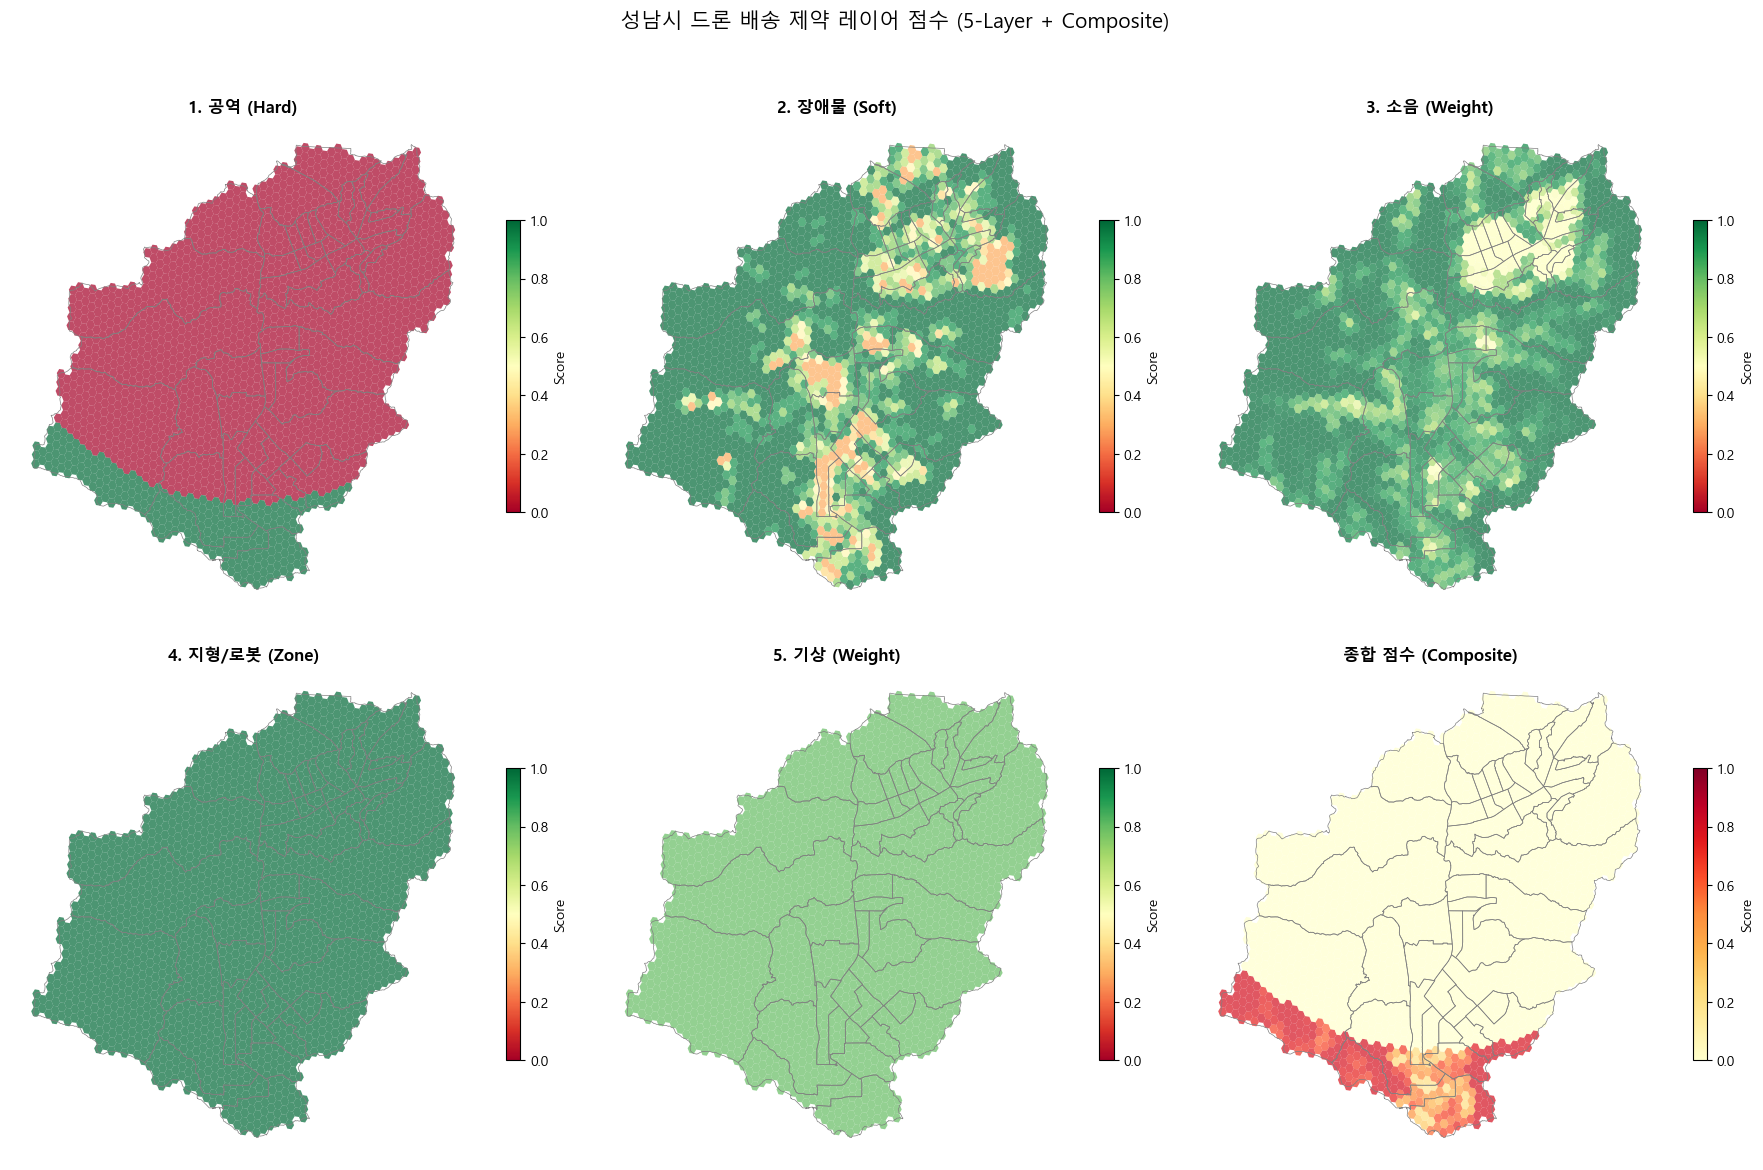

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

seongnam = gpd.read_file(OUT / "seongnam_boundary.gpkg", layer="dong")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

layers = [
    ("score_airspace", "1. 공역 (Hard)", "RdYlGn"),
    ("score_obstacle", "2. 장애물 (Soft)", "RdYlGn"),
    ("score_noise", "3. 소음 (Weight)", "RdYlGn"),
    ("score_terrain", "4. 지형/로봇 (Zone)", "RdYlGn"),
    ("score_weather", "5. 기상 (Weight)", "RdYlGn"),
    ("composite_score", "종합 점수 (Composite)", "YlOrRd"),
]

for ax, (col, title, cmap) in zip(axes.flat, layers):
    seongnam.boundary.plot(ax=ax, color="gray", linewidth=0.5)
    gdf.plot(
        ax=ax, column=col, cmap=cmap, legend=True,
        alpha=0.7, edgecolor="none", vmin=0, vmax=1,
        legend_kwds={"shrink": 0.5, "label": "Score"},
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()

plt.suptitle("성남시 드론 배송 제약 레이어 점수 (5-Layer + Composite)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 8. 저장

In [9]:
# 저장할 컬럼 정리
keep_cols = [
    "h3_index", "lat", "lon", "geometry",
    "CSV_ADMI_CD", "ADM_NM", "GU_NM",
    "delivery_demand_index", "flow_pop_index", "urgency",
    "score_airspace", "score_obstacle", "score_noise",
    "score_terrain", "score_weather", "composite_score",
    "tall_bldg_count", "total_bldg_count",
    "avg_slope", "terrain_zone",
]
# 존재하는 컬럼만 선택
keep_cols = [c for c in keep_cols if c in gdf.columns]
gdf_out = gdf[keep_cols].copy()

# GeoPackage 저장
gdf_out.to_file(OUT / "constraint_layers.gpkg", driver="GPKG")
print(f"저장 완료: {OUT / 'constraint_layers.gpkg'}")
print(f"  셀 수: {len(gdf_out)}")
print(f"  컬럼: {gdf_out.columns.tolist()}")

# Tableau용 CSV도 함께 저장 (geometry 제외, lat/lon으로 대체)
csv_out = gdf_out.drop(columns="geometry")
csv_out.to_csv(OUT / "constraint_layers.csv", index=False, encoding="utf-8-sig")
print(f"  CSV: {OUT / 'constraint_layers.csv'}")

저장 완료: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\constraint_layers.gpkg
  셀 수: 1947
  컬럼: ['h3_index', 'lat', 'lon', 'geometry', 'CSV_ADMI_CD', 'ADM_NM', 'GU_NM', 'delivery_demand_index', 'flow_pop_index', 'urgency', 'score_airspace', 'score_obstacle', 'score_noise', 'score_terrain', 'score_weather', 'composite_score', 'tall_bldg_count', 'total_bldg_count', 'avg_slope', 'terrain_zone']
  CSV: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\constraint_layers.csv
